# Observed SOH Without Charging Events, Plus Charge-Event Spike Diagnostics

This notebook follows two simple questions:

1. What happens to the observed SOH timeline if we throw away charging events?
2. For charging events that still align with big upward SOH jumps, what inside the charge trace looks suspicious?

The goal is not to prove a final cause. The goal is to separate two possibilities:

- the observed SOH spikes are mostly a charging-event artifact,
- or the charging event is where the estimator updates, while the effect also carries into the next non-charging event.


In [14]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'ml_workspace').exists() and (candidate / 'data').exists():
            return candidate
    raise RuntimeError('Could not locate project root from notebook working directory.')


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)


## Configuration

- `FOCUS_PLANE` is the main aircraft for the plots.
- `SPIKE_THRESHOLD_PCT` defines what counts as an upward SOH jump.
- `TOP_N_CHARGE_SPIKES` controls how many charging events we inspect in detail.


In [15]:
TIMESERIES_PATH = PROJECT_ROOT / 'data' / 'event_timeseries.parquet'
PLANES = ['166', '192']
FOCUS_PLANE = '166'
SPIKE_THRESHOLD_PCT = 2.0
TOP_N_CHARGE_SPIKES = 10


## Build Event-Level Observed SOH Timeline

We aggregate one row per `(plane_id, flight_id, event_datetime, battery_id)` from the aux parquet.

For each event we keep:

- median observed SOH,
- event type,
- event duration from `time_ms`.


In [16]:
def load_event_level_observed_soh(timeseries_path: Path, planes: list[str]) -> pd.DataFrame:
    dataset = ds.dataset(str(timeseries_path), format='parquet')
    pack_frames = []
    for pack_id in (1, 2):
        p = str(pack_id)
        cols = [
            'plane_id',
            'flight_id',
            'event_datetime',
            'is_flight_event',
            'is_charging_event',
            'source_csv_kind',
            'source_pack_id',
            'time_ms',
            f' bat {p} soh',
        ]
        table = dataset.to_table(
            columns=cols,
            filter=(
                ds.field('plane_id').isin(planes)
                & (ds.field('source_csv_kind') == 'aux')
                & (ds.field('source_pack_id') == pack_id)
            ),
        )
        frame = table.to_pandas().rename(columns={f' bat {p} soh': 'observed_soh_pct'})
        frame['battery_id'] = pack_id
        pack_frames.append(frame)

    raw = pd.concat(pack_frames, ignore_index=True)
    raw['event_datetime'] = pd.to_datetime(raw['event_datetime'], errors='coerce')
    raw['observed_soh_pct'] = pd.to_numeric(raw['observed_soh_pct'], errors='coerce')
    raw['time_ms'] = pd.to_numeric(raw['time_ms'], errors='coerce')
    raw = raw.dropna(subset=['event_datetime'])

    event_df = raw.groupby(['plane_id', 'flight_id', 'event_datetime', 'battery_id'], as_index=False).agg(
        observed_soh_pct=('observed_soh_pct', 'median'),
        time_ms_min=('time_ms', 'min'),
        time_ms_max=('time_ms', 'max'),
        is_flight_event=('is_flight_event', 'max'),
        is_charging_event=('is_charging_event', 'max'),
    )
    event_df['event_duration_min'] = (event_df['time_ms_max'] - event_df['time_ms_min']) / 60000.0
    event_df['event_duration_min'] = event_df['event_duration_min'].clip(lower=0.0)
    event_df['event_type'] = np.where(
        event_df['is_flight_event'] == 1,
        'flight',
        np.where(event_df['is_charging_event'] == 1, 'charge', 'other'),
    )
    return event_df.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)


event_df = load_event_level_observed_soh(TIMESERIES_PATH, PLANES)
event_df.head()


,plane_id,flight_id,event_datetime,battery_id,observed_soh_pct,time_ms_min,time_ms_max,is_flight_event,is_charging_event,event_duration_min,event_type
0,166,4575,2023-05-16 11:00:00,1,100.0,2674.612,3151448.406,0,1,52.479563,charge
1,166,4576,2023-05-16 12:44:00,1,100.0,2479.405,1929865.006,0,0,32.123093,other
2,166,4577,2023-05-16 13:00:00,1,97.0,2276.321,3756859.640,0,1,62.576389,charge
3,166,4578,2023-05-16 14:35:00,1,97.0,2081.891,2283664.522,0,0,38.026377,other
4,166,4579,2023-05-16 15:00:00,1,96.0,2078.169,4186256.797,0,1,69.736310,charge


In [17]:
def add_soh_step_features(event_df: pd.DataFrame) -> pd.DataFrame:
    parts = []
    for (plane_id, battery_id), group in event_df.groupby(['plane_id', 'battery_id'], sort=True):
        g = group.sort_values(['event_datetime', 'flight_id']).reset_index(drop=True).copy()
        g['prev_soh_all'] = g['observed_soh_pct'].shift(1)
        g['delta_soh_all'] = g['observed_soh_pct'] - g['prev_soh_all']

        non_charge = g.loc[g['event_type'] != 'charge', ['flight_id', 'observed_soh_pct']].copy()
        non_charge['prev_soh_no_charge'] = non_charge['observed_soh_pct'].shift(1)
        non_charge['delta_soh_no_charge'] = non_charge['observed_soh_pct'] - non_charge['prev_soh_no_charge']
        g = g.merge(non_charge[['flight_id', 'prev_soh_no_charge', 'delta_soh_no_charge']], on='flight_id', how='left')

        flight_only = g.loc[g['event_type'] == 'flight', ['flight_id', 'observed_soh_pct']].copy()
        flight_only['prev_soh_flight_only'] = flight_only['observed_soh_pct'].shift(1)
        flight_only['delta_soh_flight_only'] = flight_only['observed_soh_pct'] - flight_only['prev_soh_flight_only']
        g = g.merge(flight_only[['flight_id', 'prev_soh_flight_only', 'delta_soh_flight_only']], on='flight_id', how='left')
        parts.append(g)
    return pd.concat(parts, ignore_index=True).sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)


analysis_df = add_soh_step_features(event_df)
analysis_df.head()


,plane_id,flight_id,event_datetime,battery_id,observed_soh_pct,time_ms_min,time_ms_max,is_flight_event,is_charging_event,event_duration_min,event_type,prev_soh_all,delta_soh_all,prev_soh_no_charge,delta_soh_no_charge,prev_soh_flight_only,delta_soh_flight_only
0,166,4575,2023-05-16 11:00:00,1,100.0,2674.612,3151448.406,0,1,52.479563,charge,NaN,NaN,NaN,NaN,NaN,NaN
1,166,4576,2023-05-16 12:44:00,1,100.0,2479.405,1929865.006,0,0,32.123093,other,100.0,0.0,NaN,NaN,NaN,NaN
2,166,4577,2023-05-16 13:00:00,1,97.0,2276.321,3756859.640,0,1,62.576389,charge,100.0,-3.0,NaN,NaN,NaN,NaN
3,166,4578,2023-05-16 14:35:00,1,97.0,2081.891,2283664.522,0,0,38.026377,other,97.0,0.0,100.0,-3.0,NaN,NaN
4,166,4579,2023-05-16 15:00:00,1,96.0,2078.169,4186256.797,0,1,69.736310,charge,97.0,-1.0,NaN,NaN,NaN,NaN


## Spike Count Comparison

This is the main first check.

We compare upward SOH spikes in three timelines:

- `all events`
- `non_charge events`
- `flight_only events`


In [18]:
def count_spikes(series: pd.Series, threshold: float) -> int:
    return int(pd.to_numeric(series, errors='coerce').ge(threshold).sum())


rows = []
for (plane_id, battery_id), group in analysis_df.groupby(['plane_id', 'battery_id'], sort=True):
    rows.append(
        {
            'plane_id': plane_id,
            'battery_id': battery_id,
            'all_event_rows': len(group),
            'all_spikes_ge_threshold': count_spikes(group['delta_soh_all'], SPIKE_THRESHOLD_PCT),
            'non_charge_rows': int((group['event_type'] != 'charge').sum()),
            'non_charge_spikes_ge_threshold': count_spikes(group['delta_soh_no_charge'], SPIKE_THRESHOLD_PCT),
            'flight_only_rows': int((group['event_type'] == 'flight').sum()),
            'flight_only_spikes_ge_threshold': count_spikes(group['delta_soh_flight_only'], SPIKE_THRESHOLD_PCT),
        }
    )
spike_count_df = pd.DataFrame(rows)
spike_count_df


,plane_id,battery_id,all_event_rows,all_spikes_ge_threshold,non_charge_rows,non_charge_spikes_ge_threshold,flight_only_rows,flight_only_spikes_ge_threshold
0,166,1,553,35,255,24,194,15
1,166,2,553,37,255,27,194,18
2,192,1,49,0,20,0,20,0
3,192,2,49,0,20,0,20,0


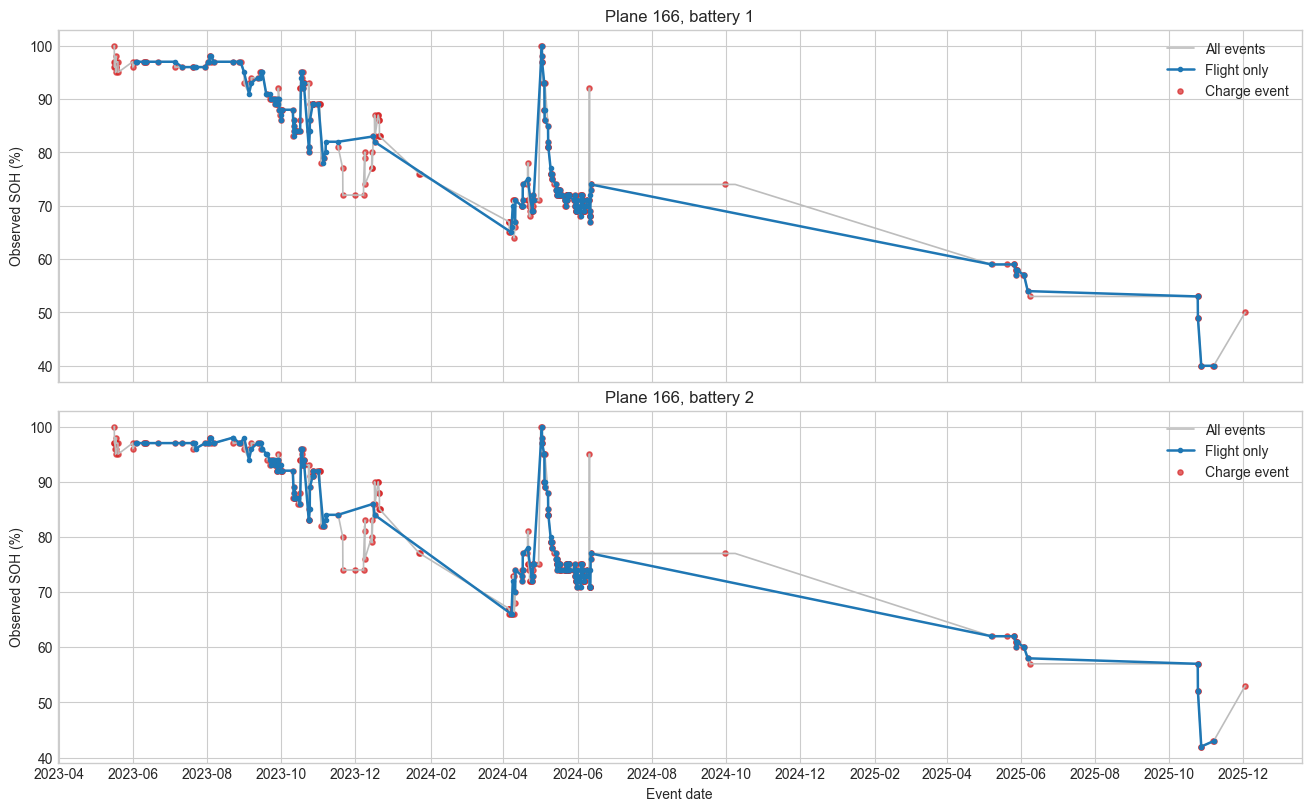

In [19]:
focus = analysis_df.loc[analysis_df['plane_id'] == FOCUS_PLANE].copy()
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, constrained_layout=True)
for ax, battery_id in zip(axes, [1, 2]):
    g = focus.loc[focus['battery_id'] == battery_id].copy()
    ax.plot(g['event_datetime'], g['observed_soh_pct'], color='#bdbdbd', linewidth=1.2, label='All events')

    flight_only = g.loc[g['event_type'] == 'flight'].copy()
    ax.plot(flight_only['event_datetime'], flight_only['observed_soh_pct'], color='#1f77b4', linewidth=1.8, marker='o', markersize=3, label='Flight only')

    charging = g.loc[g['event_type'] == 'charge'].copy()
    ax.scatter(charging['event_datetime'], charging['observed_soh_pct'], color='#d62728', s=14, alpha=0.7, label='Charge event')

    ax.set_title(f'Plane {FOCUS_PLANE}, battery {battery_id}')
    ax.set_ylabel('Observed SOH (%)')
    ax.legend(loc='best')

axes[-1].set_xlabel('Event date')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.show()


## Top Upward Jumps In Each Timeline

The tables below show whether the same jumps remain when charging events are removed or when only flight events are kept.


In [20]:
all_top = focus.dropna(subset=['delta_soh_all']).sort_values('delta_soh_all', ascending=False).groupby('battery_id').head(8)
all_top[['battery_id', 'event_datetime', 'event_type', 'observed_soh_pct', 'prev_soh_all', 'delta_soh_all']]


,battery_id,event_datetime,event_type,observed_soh_pct,prev_soh_all,delta_soh_all
307,1,2024-05-01 17:00:00,charge,100.0,71.0,29.0
860,2,2024-05-01 17:00:00,charge,100.0,75.0,25.0
1052,2,2024-06-10 19:00:00,charge,95.0,74.0,21.0
499,1,2024-06-10 19:00:00,charge,92.0,71.0,21.0
165,1,2023-10-23 17:00:00,charge,93.0,81.0,12.0
1105,2,2025-12-02 17:35:00,charge,53.0,43.0,10.0
718,2,2023-10-23 17:00:00,charge,93.0,83.0,10.0
552,1,2025-12-02 17:35:00,charge,50.0,40.0,10.0
329,1,2024-05-05 02:50:00,charge,93.0,86.0,7.0
882,2,2024-05-05 02:50:00,charge,95.0,89.0,6.0


In [21]:
flight_top = focus.loc[focus['event_type'] == 'flight'].dropna(subset=['delta_soh_flight_only']).sort_values('delta_soh_flight_only', ascending=False).groupby('battery_id').head(8)
flight_top[['battery_id', 'event_datetime', 'event_type', 'observed_soh_pct', 'prev_soh_flight_only', 'delta_soh_flight_only']]


,battery_id,event_datetime,event_type,observed_soh_pct,prev_soh_flight_only,delta_soh_flight_only
310,1,2024-05-02 15:38:00,flight,100.0,71.0,29.0
863,2,2024-05-02 15:38:00,flight,100.0,75.0,25.0
147,1,2023-10-17 11:30:00,flight,95.0,84.0,11.0
700,2,2023-10-17 11:30:00,flight,96.0,86.0,10.0
807,2,2024-04-08 16:14:00,flight,72.0,66.0,6.0
254,1,2024-04-08 16:14:00,flight,70.0,66.0,4.0
509,1,2024-06-11 15:56:00,flight,72.0,68.0,4.0
818,2,2024-04-10 21:20:00,flight,74.0,70.0,4.0
169,1,2023-10-24 11:45:00,flight,84.0,80.0,4.0
724,2,2023-10-24 14:12:00,flight,89.0,85.0,4.0


## Build Charge-Event Diagnostics

Now we focus only on charging events and ask whether anything inside the charge trace looks like a candidate cause.

Per charge event we compute:

- SOH start/end/span during charge
- maximum upward SOH step within the charge trace
- how many within-charge SOH steps exceed the spike threshold
- `cap_est` change and largest step
- Kalman-vs-coulomb gap change and largest step
- reset/re-estimation flags


In [22]:
def load_charge_event_diagnostics(timeseries_path: Path, planes: list[str]) -> pd.DataFrame:
    dataset = ds.dataset(str(timeseries_path), format='parquet')
    pack_frames = []
    for pack_id in (1, 2):
        p = str(pack_id)
        cols = [
            'plane_id',
            'flight_id',
            'event_datetime',
            'source_csv_kind',
            'source_pack_id',
            'is_charging_event',
            'time_ms',
            f' bat {p} soh',
            f' bat {p} cap est',
            f' bat {p} kalman soc',
            f' bat {p} coulomb soc out',
            f' bat {p} cell flg new est batt cap',
            f' bat {p} cell flg rst coulomb',
            f' bat {p} voltage',
            f' bat {p} current',
        ]
        table = dataset.to_table(
            columns=cols,
            filter=(
                ds.field('plane_id').isin(planes)
                & (ds.field('source_csv_kind') == 'aux')
                & (ds.field('source_pack_id') == pack_id)
                & (ds.field('is_charging_event') == 1)
            ),
        )
        frame = table.to_pandas().rename(
            columns={
                f' bat {p} soh': 'observed_soh_pct',
                f' bat {p} cap est': 'cap_est_raw',
                f' bat {p} kalman soc': 'kalman_soc_pct',
                f' bat {p} coulomb soc out': 'coulomb_soc_pct',
                f' bat {p} cell flg new est batt cap': 'flag_new_est_batt_cap',
                f' bat {p} cell flg rst coulomb': 'flag_rst_coulomb',
                f' bat {p} voltage': 'voltage_v',
                f' bat {p} current': 'current_a',
            }
        )
        frame['battery_id'] = pack_id
        pack_frames.append(frame)

    raw = pd.concat(pack_frames, ignore_index=True)
    raw['event_datetime'] = pd.to_datetime(raw['event_datetime'], errors='coerce')
    for col in ['time_ms', 'observed_soh_pct', 'cap_est_raw', 'kalman_soc_pct', 'coulomb_soc_pct', 'flag_new_est_batt_cap', 'flag_rst_coulomb', 'voltage_v', 'current_a']:
        raw[col] = pd.to_numeric(raw[col], errors='coerce')
    raw = raw.sort_values(['plane_id', 'battery_id', 'flight_id', 'time_ms']).reset_index(drop=True)

    rows = []
    for (plane_id, flight_id, event_datetime, battery_id), group in raw.groupby(['plane_id', 'flight_id', 'event_datetime', 'battery_id'], sort=True):
        g = group.sort_values('time_ms').reset_index(drop=True).copy()
        gap = g['kalman_soc_pct'] - g['coulomb_soc_pct']
        soh_diff = g['observed_soh_pct'].diff().fillna(0.0)
        cap_diff = g['cap_est_raw'].diff().fillna(0.0)
        gap_diff = gap.diff().fillna(0.0)
        positive_soh = g.loc[g['observed_soh_pct'] > 0, 'observed_soh_pct']
        rows.append(
            {
                'plane_id': plane_id,
                'flight_id': flight_id,
                'event_datetime': event_datetime,
                'battery_id': battery_id,
                'charge_soh_start': float(g['observed_soh_pct'].iloc[0]),
                'charge_soh_end': float(g['observed_soh_pct'].iloc[-1]),
                'charge_soh_span': float(g['observed_soh_pct'].max() - g['observed_soh_pct'].min()),
                'charge_soh_span_positive_only': float(positive_soh.max() - positive_soh.min()) if len(positive_soh) else np.nan,
                'max_upward_soh_step': float(soh_diff.max()),
                'max_downward_soh_step': float(soh_diff.min()),
                'count_large_soh_steps_ge_threshold': int((soh_diff >= SPIKE_THRESHOLD_PCT).sum()),
                'cap_est_start': float(g['cap_est_raw'].iloc[0]),
                'cap_est_end': float(g['cap_est_raw'].iloc[-1]),
                'cap_est_delta': float(g['cap_est_raw'].iloc[-1] - g['cap_est_raw'].iloc[0]),
                'max_cap_est_step_abs': float(cap_diff.abs().max()),
                'kalman_coulomb_gap_start': float(gap.iloc[0]),
                'kalman_coulomb_gap_end': float(gap.iloc[-1]),
                'kalman_coulomb_gap_delta': float(gap.iloc[-1] - gap.iloc[0]),
                'max_gap_step_abs': float(gap_diff.abs().max()),
                'flag_new_est_any': int((g['flag_new_est_batt_cap'].fillna(0) > 0).any()),
                'flag_rst_coulomb_any': int((g['flag_rst_coulomb'].fillna(0) > 0).any()),
                'rows': int(len(g)),
            }
        )
    return pd.DataFrame(rows).sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)


charge_diag = load_charge_event_diagnostics(TIMESERIES_PATH, PLANES)
charge_diag = charge_diag.merge(
    analysis_df[['plane_id', 'flight_id', 'event_datetime', 'battery_id', 'delta_soh_all', 'event_type']],
    on=['plane_id', 'flight_id', 'event_datetime', 'battery_id'],
    how='left',
)
charge_diag['is_upward_spike_charge_event'] = charge_diag['delta_soh_all'] >= SPIKE_THRESHOLD_PCT
charge_diag.head()


,plane_id,flight_id,event_datetime,battery_id,charge_soh_start,charge_soh_end,charge_soh_span,charge_soh_span_positive_only,max_upward_soh_step,max_downward_soh_step,count_large_soh_steps_ge_threshold,cap_est_start,cap_est_end,cap_est_delta,max_cap_est_step_abs,kalman_coulomb_gap_start,kalman_coulomb_gap_end,kalman_coulomb_gap_delta,max_gap_step_abs,flag_new_est_any,flag_rst_coulomb_any,rows,delta_soh_all,event_type,is_upward_spike_charge_event
0,166,4575,2023-05-16 11:00:00,1,100.0,100.0,0.0,0.0,0.0,0.0,0,9611.0,9611.0,0.0,0.0,1.09,0.28,-0.81,0.03,0,1,15745,NaN,charge,False
1,166,4577,2023-05-16 13:00:00,1,100.0,97.0,3.0,3.0,0.0,-2.0,0,0.0,9519.0,9519.0,9611.0,-1.33,-0.75,0.58,0.43,1,1,18774,-3.0,charge,False
2,166,4579,2023-05-16 15:00:00,1,97.0,96.0,1.0,1.0,0.0,-1.0,0,9519.0,9503.0,-16.0,7.0,-0.44,-0.31,0.13,0.18,1,1,20922,-1.0,charge,False
3,166,4581,2023-05-16 20:00:00,1,96.0,97.0,1.0,1.0,1.0,0.0,0,9503.0,9528.0,25.0,14.0,0.76,0.09,-0.67,0.27,1,1,19540,1.0,charge,False
4,166,4583,2023-05-16 22:00:00,1,0.0,97.0,97.0,0.0,97.0,0.0,1,0.0,9528.0,9528.0,9528.0,-1.05,-0.71,0.34,0.07,1,1,5728,0.0,charge,False


## Charge-Event Spike vs Non-Spike Comparison

If charging events really are special, spike charge events should look different from ordinary charge events.


In [23]:
compare_rows = []
metrics = [
    'charge_soh_span',
    'charge_soh_span_positive_only',
    'max_upward_soh_step',
    'count_large_soh_steps_ge_threshold',
    'max_cap_est_step_abs',
    'max_gap_step_abs',
    'flag_new_est_any',
    'flag_rst_coulomb_any',
]

for (plane_id, battery_id), group in charge_diag.groupby(['plane_id', 'battery_id'], sort=True):
    spike = group.loc[group['is_upward_spike_charge_event']].copy()
    non = group.loc[~group['is_upward_spike_charge_event']].copy()
    for metric in metrics:
        compare_rows.append(
            {
                'plane_id': plane_id,
                'battery_id': battery_id,
                'metric': metric,
                'spike_mean': float(spike[metric].mean()) if len(spike) else np.nan,
                'non_spike_mean': float(non[metric].mean()) if len(non) else np.nan,
                'spike_minus_non': float(spike[metric].mean() - non[metric].mean()) if len(spike) and len(non) else np.nan,
                'n_spike': int(len(spike)),
                'n_non_spike': int(len(non)),
            }
        )
comparison_df = pd.DataFrame(compare_rows)
comparison_df.loc[comparison_df['plane_id'] == FOCUS_PLANE]


,plane_id,battery_id,metric,spike_mean,non_spike_mean,spike_minus_non,n_spike,n_non_spike
0,166,1,charge_soh_span,44.760000,24.629496,20.130504,25,278
1,166,1,charge_soh_span_positive_only,2.120000,0.780576,1.339424,25,278
2,166,1,max_upward_soh_step,43.600000,24.176259,19.423741,25,278
3,166,1,count_large_soh_steps_ge_threshold,1.200000,0.356115,0.843885,25,278
4,166,1,max_cap_est_step_abs,7850.520000,7747.309353,103.210647,25,278
5,166,1,max_gap_step_abs,0.167200,25.962050,-25.794850,25,278
6,166,1,flag_new_est_any,0.800000,0.611511,0.188489,25,278
7,166,1,flag_rst_coulomb_any,0.840000,0.834532,0.005468,25,278
8,166,2,charge_soh_span,41.703704,28.061594,13.642110,27,276
9,166,2,charge_soh_span_positive_only,2.037037,0.757246,1.279791,27,276


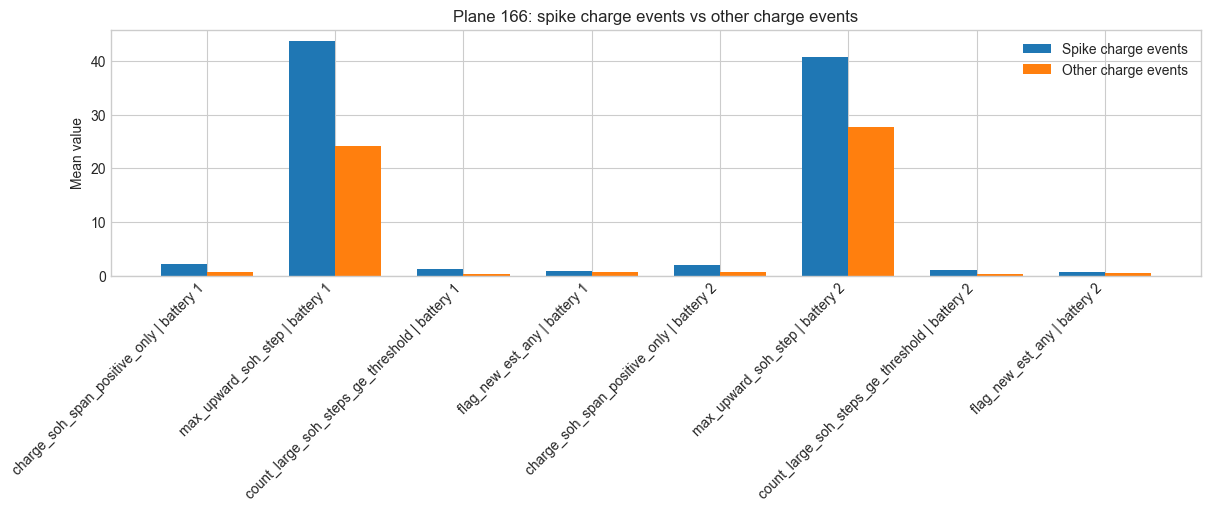

In [24]:
plot_compare = comparison_df.loc[
    (comparison_df['plane_id'] == FOCUS_PLANE)
    & (comparison_df['metric'].isin(['charge_soh_span_positive_only', 'max_upward_soh_step', 'count_large_soh_steps_ge_threshold', 'flag_new_est_any']))
].copy()
plot_compare['series'] = plot_compare['metric'] + ' | battery ' + plot_compare['battery_id'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
x = np.arange(len(plot_compare))
ax.bar(x - 0.18, plot_compare['spike_mean'], width=0.36, label='Spike charge events')
ax.bar(x + 0.18, plot_compare['non_spike_mean'], width=0.36, label='Other charge events')
ax.set_xticks(x)
ax.set_xticklabels(plot_compare['series'], rotation=45, ha='right')
ax.set_ylabel('Mean value')
ax.set_title(f'Plane {FOCUS_PLANE}: spike charge events vs other charge events')
ax.legend(loc='best')
plt.show()


## Top Charge Events Associated With Upward SOH Jumps

These are the charge events where the event-level observed SOH jumped the most relative to the previous event.


In [25]:
focus_charge_spikes = charge_diag.loc[
    (charge_diag['plane_id'] == FOCUS_PLANE)
    & (charge_diag['is_upward_spike_charge_event'])
].sort_values('delta_soh_all', ascending=False).reset_index(drop=True)

focus_charge_spikes[
    [
        'battery_id',
        'event_datetime',
        'delta_soh_all',
        'charge_soh_span',
        'charge_soh_span_positive_only',
        'max_upward_soh_step',
        'count_large_soh_steps_ge_threshold',
        'max_cap_est_step_abs',
        'max_gap_step_abs',
        'flag_new_est_any',
        'flag_rst_coulomb_any',
        'rows',
    ]
].head(12)


,battery_id,event_datetime,delta_soh_all,charge_soh_span,charge_soh_span_positive_only,max_upward_soh_step,count_large_soh_steps_ge_threshold,max_cap_est_step_abs,max_gap_step_abs,flag_new_est_any,flag_rst_coulomb_any,rows
0,1,2024-05-01 17:00:00,29.0,0.0,0.0,0.0,0,0.0,0.06,0,0,10859
1,2,2024-05-01 17:00:00,25.0,0.0,0.0,0.0,0,0.0,0.05,0,0,10859
2,1,2024-06-10 19:00:00,21.0,92.0,2.0,90.0,2,9462.0,0.06,1,1,14951
3,2,2024-06-10 19:00:00,21.0,95.0,1.0,94.0,1,9467.0,0.08,1,1,14949
4,1,2023-10-23 17:00:00,12.0,0.0,0.0,0.0,0,9367.0,0.01,1,1,45363
5,2,2025-12-02 17:35:00,10.0,53.0,0.0,53.0,1,8973.0,0.38,0,1,4547
6,2,2023-10-23 17:00:00,10.0,0.0,0.0,0.0,0,9388.0,0.01,1,1,45363
7,1,2025-12-02 17:35:00,10.0,50.0,0.0,50.0,1,8895.0,2.84,1,1,4547
8,1,2024-05-05 02:50:00,7.0,93.0,0.0,93.0,1,9480.0,0.01,0,1,13789
9,1,2023-12-15 17:05:00,6.0,83.0,4.0,79.0,2,9250.0,0.02,1,1,22919


## Plot Raw Charge Traces For The Biggest Charge-Event Spikes

These plots show what happens inside the charge events themselves.

What to look for:

- abrupt steps in observed SOH during charge,
- very large `cap_est` jumps,
- changes in Kalman-vs-coulomb gap,
- reset or re-estimation flags becoming active.


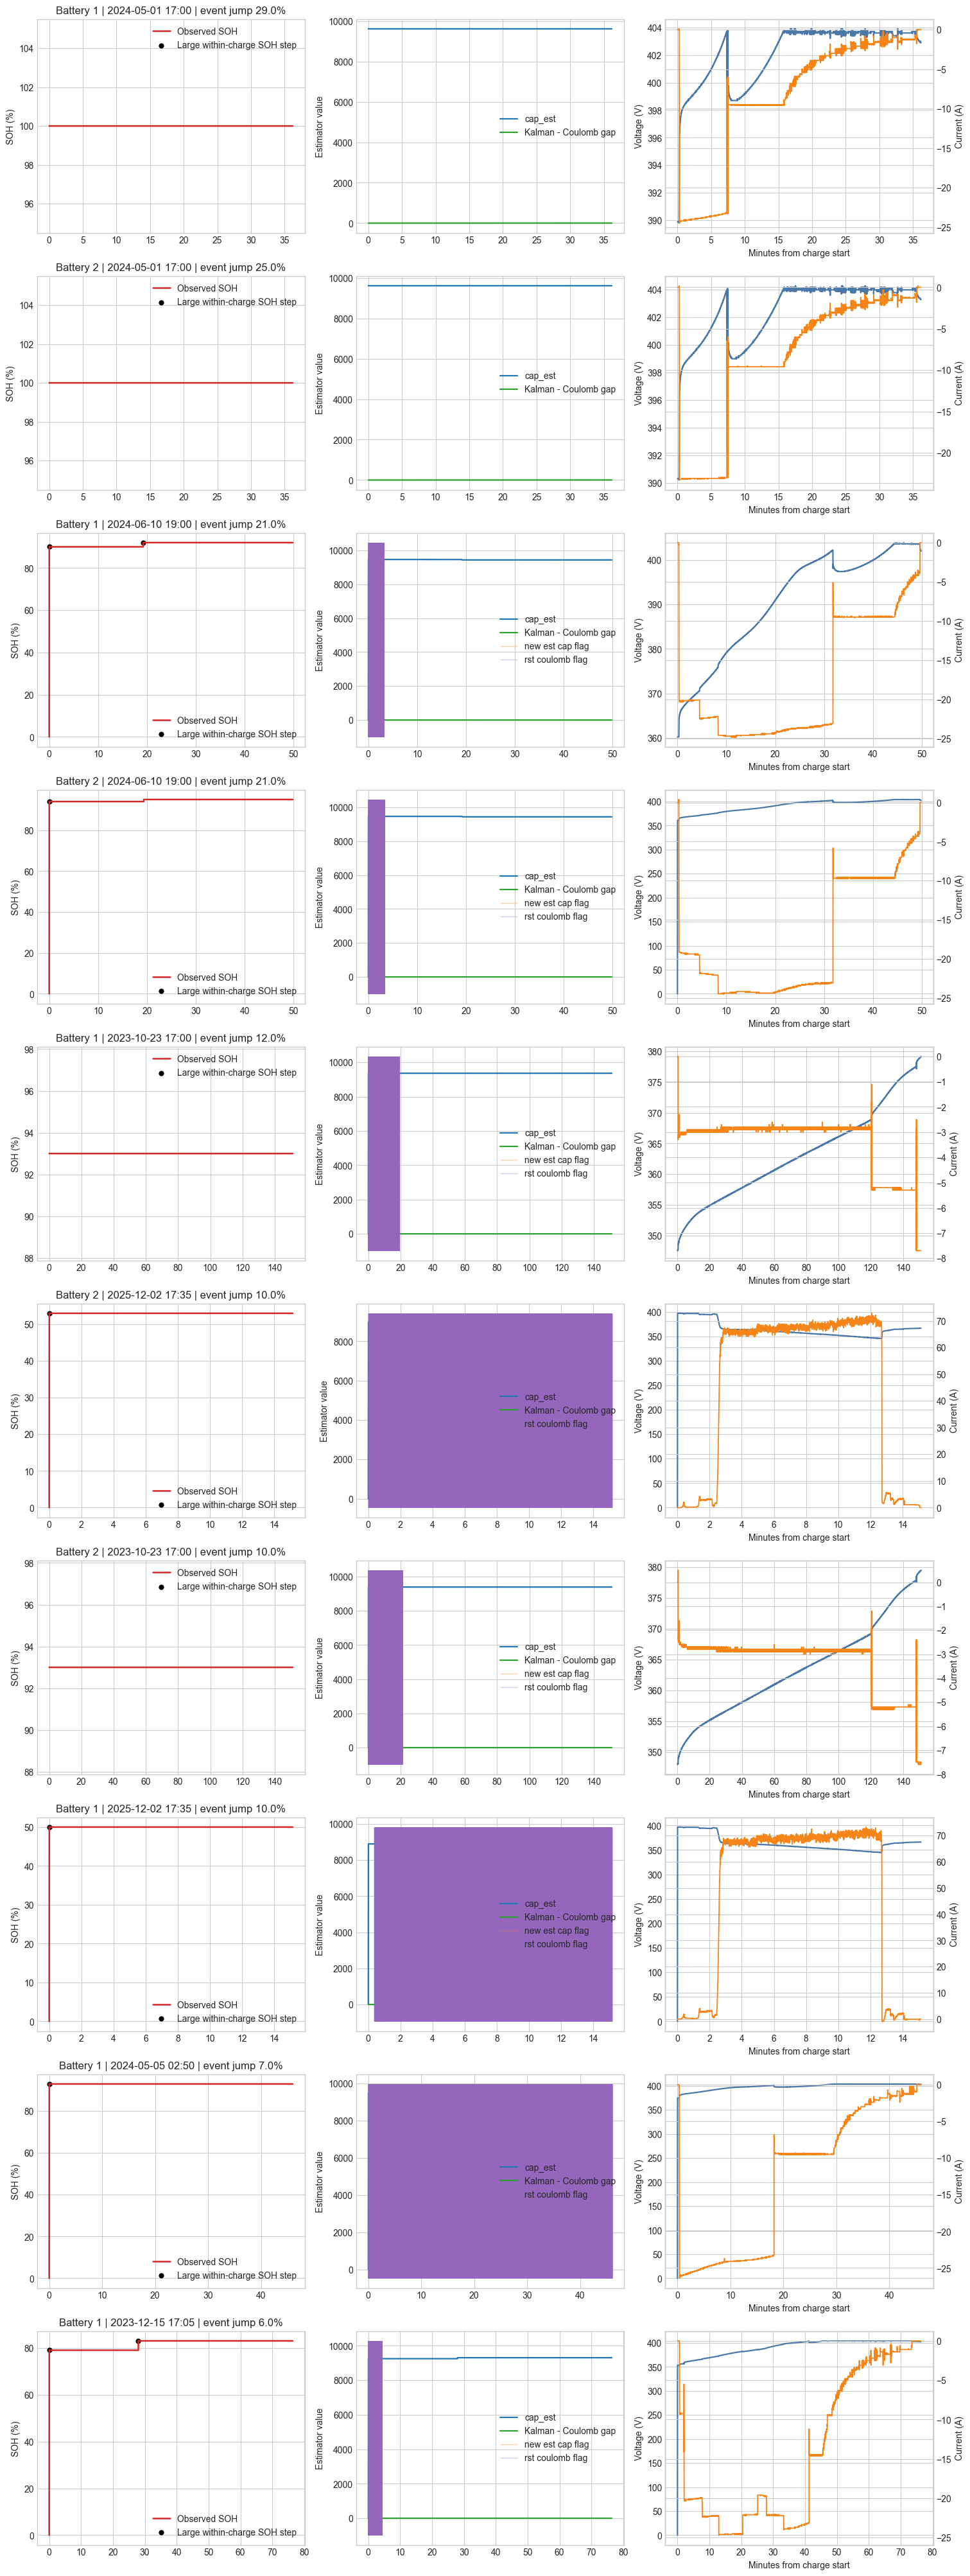

In [26]:
def load_charge_trace(timeseries_path: Path, plane_id: str, battery_id: int, flight_id: int) -> pd.DataFrame:
    dataset = ds.dataset(str(timeseries_path), format='parquet')
    p = str(battery_id)
    cols = [
        'plane_id',
        'flight_id',
        'event_datetime',
        'source_csv_kind',
        'source_pack_id',
        'is_charging_event',
        'time_ms',
        f' bat {p} soh',
        f' bat {p} cap est',
        f' bat {p} kalman soc',
        f' bat {p} coulomb soc out',
        f' bat {p} cell flg new est batt cap',
        f' bat {p} cell flg rst coulomb',
        f' bat {p} voltage',
        f' bat {p} current',
    ]
    table = dataset.to_table(
        columns=cols,
        filter=(
            (ds.field('plane_id') == str(plane_id))
            & (ds.field('source_csv_kind') == 'aux')
            & (ds.field('source_pack_id') == battery_id)
            & (ds.field('flight_id') == int(flight_id))
            & (ds.field('is_charging_event') == 1)
        ),
    )
    df = table.to_pandas().rename(
        columns={
            f' bat {p} soh': 'observed_soh_pct',
            f' bat {p} cap est': 'cap_est_raw',
            f' bat {p} kalman soc': 'kalman_soc_pct',
            f' bat {p} coulomb soc out': 'coulomb_soc_pct',
            f' bat {p} cell flg new est batt cap': 'flag_new_est_batt_cap',
            f' bat {p} cell flg rst coulomb': 'flag_rst_coulomb',
            f' bat {p} voltage': 'voltage_v',
            f' bat {p} current': 'current_a',
        }
    )
    df = df.sort_values('time_ms').reset_index(drop=True)
    for col in ['time_ms', 'observed_soh_pct', 'cap_est_raw', 'kalman_soc_pct', 'coulomb_soc_pct', 'flag_new_est_batt_cap', 'flag_rst_coulomb', 'voltage_v', 'current_a']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['time_min_from_start'] = (df['time_ms'] - df['time_ms'].iloc[0]) / 60000.0
    df['kalman_coulomb_gap'] = df['kalman_soc_pct'] - df['coulomb_soc_pct']
    return df


def plot_charge_trace_detail(ax_row, trace_df: pd.DataFrame, title: str) -> None:
    t = trace_df['time_min_from_start']
    soh_diff = trace_df['observed_soh_pct'].diff().fillna(0.0)
    big_steps = trace_df.loc[soh_diff >= SPIKE_THRESHOLD_PCT].copy()
    new_flag = trace_df.loc[trace_df['flag_new_est_batt_cap'].fillna(0) > 0].copy()
    rst_flag = trace_df.loc[trace_df['flag_rst_coulomb'].fillna(0) > 0].copy()

    ax0, ax1, ax2 = ax_row
    ax0.plot(t, trace_df['observed_soh_pct'], color='#d62728', linewidth=1.8, label='Observed SOH')
    ax0.scatter(big_steps['time_min_from_start'], big_steps['observed_soh_pct'], color='black', s=24, label='Large within-charge SOH step')
    ax0.set_ylabel('SOH (%)')
    ax0.set_title(title)
    ax0.legend(loc='best')

    ax1.plot(t, trace_df['cap_est_raw'], color='#1f77b4', linewidth=1.6, label='cap_est')
    ax1.plot(t, trace_df['kalman_coulomb_gap'], color='#2ca02c', linewidth=1.6, label='Kalman - Coulomb gap')
    if not new_flag.empty:
        ax1.vlines(new_flag['time_min_from_start'], ymin=ax1.get_ylim()[0], ymax=ax1.get_ylim()[1], color='#ff7f0e', alpha=0.35, linewidth=1.0, label='new est cap flag')
    if not rst_flag.empty:
        ax1.vlines(rst_flag['time_min_from_start'], ymin=ax1.get_ylim()[0], ymax=ax1.get_ylim()[1], color='#9467bd', alpha=0.35, linewidth=1.0, label='rst coulomb flag')
    ax1.set_ylabel('Estimator value')
    ax1.legend(loc='best')

    ax2.plot(t, trace_df['voltage_v'], color='#4c78a8', linewidth=1.6, label='Voltage')
    ax2_twin = ax2.twinx()
    ax2_twin.plot(t, trace_df['current_a'], color='#f58518', linewidth=1.3, label='Current')
    ax2.set_ylabel('Voltage (V)')
    ax2_twin.set_ylabel('Current (A)')
    ax2.set_xlabel('Minutes from charge start')


selected_spikes = focus_charge_spikes.head(TOP_N_CHARGE_SPIKES).copy()
fig, axes = plt.subplots(len(selected_spikes), 3, figsize=(15, 4 * len(selected_spikes)), constrained_layout=True)
if len(selected_spikes) == 1:
    axes = np.array([axes])

for ax_row, (_, row) in zip(axes, selected_spikes.iterrows()):
    trace = load_charge_trace(TIMESERIES_PATH, row['plane_id'], int(row['battery_id']), int(row['flight_id']))
    title = f"Battery {int(row['battery_id'])} | {pd.Timestamp(row['event_datetime']).strftime('%Y-%m-%d %H:%M')} | event jump {row['delta_soh_all']:.1f}%"
    plot_charge_trace_detail(ax_row, trace, title)

plt.show()


## What To Take Away

This notebook is meant to answer a narrower question than the earlier idle-time notebook.

The main checks are:

1. Does the spike count drop if charging events are removed?
2. Does a stricter flight-only timeline look materially cleaner?
3. Do spike-associated charging events show direct within-charge SOH steps, large estimator jumps, or reset/re-estimation flags?

If the answer to those is yes, then the observed SOH stream should not be treated as a clean ground-truth label without charge-aware filtering or a latent-target model.
